# 09 — Build the analytics layer

**Business objective**: transform raw transactional data (`data/raw/`) into
clean, business-entity-shaped analytical tables (`data/analytics/`) that
become the single source of truth for everything downstream — dashboards,
ML models, forecasting, the API layer, and AI agents.

**This notebook is not**: machine learning, a dashboard, or a place for
one-off exploratory analysis. It only builds and validates tables.

**Contract**: reads only from `data/raw/`, writes only to `data/analytics/`,
never modifies the raw CSVs, and runs top-to-bottom with no manual steps.

## Reference date

Several tables need a notion of "today" (days since last purchase, recent
sales for stockout estimation, active/inactive flags). We use
`max(orders.order_date)` across the whole dataset as that reference point,
rather than the actual system clock — the dataset is static, so "today"
should be *whatever day the data was generated as of*, not whenever this
notebook happens to be re-run. This is documented once here and reused
everywhere below instead of being silently recomputed per table.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 20)
plt.rcParams["figure.figsize"] = (9, 4)

RAW_DIR = Path("../data/raw")
OUT_DIR = Path("../data/analytics")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Reading from : {RAW_DIR.resolve()}")
print(f"Writing to   : {OUT_DIR.resolve()}")

Reading from : /home/claude/project/eaida/data/raw
Writing to   : /home/claude/project/eaida/data/analytics


In [2]:
customers   = pd.read_csv(RAW_DIR / "customers.csv", parse_dates=["signup_date"])
stores      = pd.read_csv(RAW_DIR / "stores.csv", parse_dates=["open_date"])
products    = pd.read_csv(RAW_DIR / "products.csv")
orders      = pd.read_csv(RAW_DIR / "orders.csv", parse_dates=["order_date"])
order_items = pd.read_csv(RAW_DIR / "order_items.csv")
inventory   = pd.read_csv(RAW_DIR / "inventory.csv", parse_dates=["snapshot_date"])
returns     = pd.read_csv(RAW_DIR / "returns.csv", parse_dates=["return_date"])
campaigns   = pd.read_csv(RAW_DIR / "marketing_campaigns.csv", parse_dates=["start_date", "end_date"])

TODAY = orders["order_date"].max()
print(f"Reference date (TODAY) = {TODAY.date()}")

for name, df in [("customers", customers), ("stores", stores), ("products", products),
                  ("orders", orders), ("order_items", order_items), ("inventory", inventory),
                  ("returns", returns), ("marketing_campaigns", campaigns)]:
    print(f"{name:<22} {len(df):>8,} rows")

Reference date (TODAY) = 2026-07-01
customers                 5,000 rows
stores                        8 rows
products                    200 rows
orders                   35,591 rows
order_items              67,743 rows
inventory                28,000 rows
returns                   1,707 rows
marketing_campaigns          30 rows


## Reusable helpers

Two small functions, used by every table below, so validation logic and
save logic are each written exactly once.

`validate_table` doesn't raise on failure — it records the result. A single
analytics table failing validation shouldn't crash the whole notebook and
silently produce zero output tables; better to build everything, then show
a validation summary at the end that makes any failure impossible to miss.

In [3]:
validation_results = []  # (table_name, check_name, passed, detail)

def validate_table(table_name: str, df: pd.DataFrame, pk_cols, non_negative_cols=None,
                    expected_min_rows: int = 1):
    """Runs the standard battery of checks for one analytics table and records results."""
    non_negative_cols = non_negative_cols or []

    dup_count = df.duplicated(subset=pk_cols).sum()
    validation_results.append(
        (table_name, f"unique primary key {pk_cols}", dup_count == 0, f"{dup_count} duplicate(s)")
    )

    missing_pk = df[pk_cols].isnull().any(axis=1).sum()
    validation_results.append(
        (table_name, f"no missing primary key {pk_cols}", missing_pk == 0, f"{missing_pk} missing")
    )

    for col in non_negative_cols:
        neg_count = (df[col] < 0).sum()
        validation_results.append(
            (table_name, f"{col} >= 0", neg_count == 0, f"{neg_count} negative row(s)")
        )

    validation_results.append(
        (table_name, f"row count >= {expected_min_rows}", len(df) >= expected_min_rows, f"{len(df)} rows")
    )


def save_table(df: pd.DataFrame, filename: str):
    path = OUT_DIR / filename
    df.to_csv(path, index=False)
    print(f"Wrote {len(df):,} rows x {len(df.columns)} cols -> {path}")

## Table 1 — `customer_summary.csv`

One row per customer. Revenue-bearing fields (`total_orders`,
`total_items`, `total_spent`, `average_order_value`) are computed from
**completed orders only** — a cancelled order was never fulfilled, so
counting it as "business" would overstate a customer's real value. This is
the same convention already used in the Day 3/4 SQL views, kept consistent
here rather than redefined per table.

`is_active` = placed a completed order within the last 90 days of `TODAY`.
90 days is a judgment call for an MVP retailer, not derived from the data —
flagged here rather than left implicit.

In [4]:
completed_orders = orders[orders["order_status"] == "completed"].copy()

items_with_order = order_items.merge(
    completed_orders[["order_id", "customer_id", "order_date"]], on="order_id", how="inner"
)

per_customer_orders = completed_orders.groupby("customer_id").agg(
    first_order_date=("order_date", "min"),
    last_order_date=("order_date", "max"),
    total_orders=("order_id", "nunique"),
).reset_index()

per_customer_items = items_with_order.groupby("customer_id").agg(
    total_items=("quantity", "sum"),
    total_spent=("line_total", "sum"),
).reset_index()

customer_summary = (
    customers[["customer_id", "signup_date"]]
    .merge(per_customer_orders, on="customer_id", how="left")
    .merge(per_customer_items, on="customer_id", how="left")
)

for col in ["total_orders", "total_items", "total_spent"]:
    customer_summary[col] = customer_summary[col].fillna(0)

customer_summary["average_order_value"] = (
    customer_summary["total_spent"] / customer_summary["total_orders"].replace(0, np.nan)
).fillna(0).round(2)

customer_summary["days_since_last_purchase"] = (
    TODAY - customer_summary["last_order_date"]
).dt.days  # NaN (via NaT) for customers who never ordered -- correct, not a bug

customer_summary["lifetime_days"] = (TODAY - customer_summary["signup_date"]).dt.days

customer_summary["is_active"] = customer_summary["days_since_last_purchase"] <= 90

customer_summary["total_spent"] = customer_summary["total_spent"].round(2)

customer_summary = customer_summary[[
    "customer_id", "signup_date", "first_order_date", "last_order_date",
    "total_orders", "total_items", "total_spent", "average_order_value",
    "days_since_last_purchase", "lifetime_days", "is_active",
]]

customer_summary.head()

,customer_id,signup_date,first_order_date,last_order_date,total_orders,total_items,total_spent,average_order_value,days_since_last_purchase,lifetime_days,is_active
0,1,2023-03-20,2025-05-18,2026-04-20,12.0,41.0,3563.83,296.99,72.0,1199,True
1,2,2026-05-22,2026-06-29,2026-06-29,1.0,2.0,515.44,515.44,2.0,40,True
2,3,2026-01-23,2026-01-28,2026-06-11,6.0,20.0,2765.29,460.88,20.0,159,True
3,4,2023-04-09,2025-01-17,2026-06-05,11.0,28.0,2492.76,226.61,26.0,1179,True
4,5,2026-05-21,NaT,NaT,0.0,0.0,0.00,0.00,NaN,41,False


In [5]:
# Impossible-dates check is specific to this table (first order before signup),
# so it's checked here directly rather than folded into the generic helper.
impossible_dates = (customer_summary["first_order_date"] < customer_summary["signup_date"]).sum()
validation_results.append(
    ("customer_summary", "no order before signup_date", impossible_dates == 0, f"{impossible_dates} violation(s)")
)

validate_table("customer_summary", customer_summary, pk_cols=["customer_id"],
                non_negative_cols=["total_spent", "total_orders", "total_items"],
                expected_min_rows=len(customers))

save_table(customer_summary, "customer_summary.csv")

Wrote 5,000 rows x 11 cols -> ../data/analytics/customer_summary.csv


## Table 2 — `daily_sales.csv`

One row per store per day. `cancelled_orders` is tracked as its own column
rather than being dropped — an enterprise analytics table should let a
downstream consumer see cancellation volume, not just hide it by filtering
before aggregation.

Every (store, date) combination in the order history range is included,
even zero-order days — a store with a gap in the table would be
indistinguishable from a store that didn't exist yet, which is the wrong
failure mode for a "single source of truth" table.

In [6]:
order_date_range = pd.date_range(orders["order_date"].min(), orders["order_date"].max(), freq="D")
store_date_scaffold = pd.MultiIndex.from_product(
    [order_date_range, stores["store_id"]], names=["date", "store_id"]
).to_frame(index=False)

completed_items = order_items.merge(
    completed_orders[["order_id", "customer_id", "store_id", "order_date"]], on="order_id", how="inner"
)

daily_completed = completed_orders.groupby(["order_date", "store_id"]).agg(
    orders=("order_id", "nunique"),
    customers=("customer_id", "nunique"),
).reset_index().rename(columns={"order_date": "date"})

daily_units_revenue = completed_items.groupby(["order_date", "store_id"]).agg(
    units_sold=("quantity", "sum"),
    revenue=("line_total", "sum"),
).reset_index().rename(columns={"order_date": "date"})

daily_cancelled = (
    orders[orders["order_status"] == "cancelled"]
    .groupby(["order_date", "store_id"]).size().reset_index(name="cancelled_orders")
    .rename(columns={"order_date": "date"})
)

daily_sales = (
    store_date_scaffold
    .merge(daily_completed, on=["date", "store_id"], how="left")
    .merge(daily_units_revenue, on=["date", "store_id"], how="left")
    .merge(daily_cancelled, on=["date", "store_id"], how="left")
    .merge(stores[["store_id", "city"]], on="store_id", how="left")
)

for col in ["orders", "customers", "units_sold", "revenue", "cancelled_orders"]:
    daily_sales[col] = daily_sales[col].fillna(0)

daily_sales["average_order_value"] = (
    daily_sales["revenue"] / daily_sales["orders"].replace(0, np.nan)
).fillna(0).round(2)
daily_sales["revenue"] = daily_sales["revenue"].round(2)

daily_sales = daily_sales[[
    "date", "store_id", "city", "orders", "customers", "units_sold",
    "revenue", "average_order_value", "cancelled_orders",
]].sort_values(["date", "store_id"]).reset_index(drop=True)

daily_sales.head()

,date,store_id,city,orders,customers,units_sold,revenue,average_order_value,cancelled_orders
0,2025-01-01,1,Sydney,4.0,4.0,9.0,1702.74,425.68,0.0
1,2025-01-01,2,Sydney,6.0,6.0,17.0,1279.93,213.32,0.0
2,2025-01-01,3,Melbourne,2.0,2.0,2.0,71.70,35.85,0.0
3,2025-01-01,4,Melbourne,6.0,6.0,22.0,2597.23,432.87,0.0
4,2025-01-01,5,Brisbane,6.0,6.0,11.0,1862.66,310.44,0.0


In [7]:
validate_table("daily_sales", daily_sales, pk_cols=["date", "store_id"],
                non_negative_cols=["revenue", "orders", "units_sold"],
                expected_min_rows=len(order_date_range) * len(stores))
save_table(daily_sales, "daily_sales.csv")

Wrote 4,376 rows x 9 cols -> ../data/analytics/daily_sales.csv


## Table 3 — `monthly_sales.csv`

One row per month. `orders`, `units_sold`, and `revenue` are simple sums
of `daily_sales` — those are additive, so re-deriving them from raw orders
would just be duplicated logic for the same answer.

`customers` is **not** summed from `daily_sales.customers`: summing daily
distinct-customer counts across a month double-counts every customer who
ordered more than once that month. It's recomputed here as a genuine
`nunique` over completed orders per month, straight from source. This is
exactly the kind of trap a "just aggregate the daily table" approach falls
into, called out explicitly rather than silently getting it wrong.

In [8]:
monthly_from_daily = (
    daily_sales.assign(month=daily_sales["date"].dt.to_period("M").dt.to_timestamp())
    .groupby("month").agg(orders=("orders", "sum"), units_sold=("units_sold", "sum"),
                           revenue=("revenue", "sum"))
    .reset_index()
)

monthly_customers = (
    completed_orders.assign(month=completed_orders["order_date"].dt.to_period("M").dt.to_timestamp())
    .groupby("month")["customer_id"].nunique().reset_index(name="customers")
)

monthly_sales = monthly_from_daily.merge(monthly_customers, on="month", how="left")
monthly_sales["customers"] = monthly_sales["customers"].fillna(0)
monthly_sales["average_order_value"] = (
    monthly_sales["revenue"] / monthly_sales["orders"].replace(0, np.nan)
).fillna(0).round(2)
monthly_sales["revenue"] = monthly_sales["revenue"].round(2)

monthly_sales = monthly_sales[[
    "month", "orders", "customers", "units_sold", "revenue", "average_order_value"
]].sort_values("month").reset_index(drop=True)

monthly_sales.rename(columns={"month": "month_date"}, inplace=True)
monthly_sales.insert(0, "month", monthly_sales["month_date"].dt.strftime("%Y-%m"))
monthly_sales = monthly_sales.drop(columns=["month_date"])

monthly_sales.head()

,month,orders,customers,units_sold,revenue,average_order_value
0,2025-01,1265.0,998,3958.0,621380.65,491.21
1,2025-02,1251.0,1004,3941.0,617859.93,493.89
2,2025-03,1436.0,1113,4560.0,712733.23,496.33
3,2025-04,1463.0,1168,4588.0,682026.66,466.18
4,2025-05,1566.0,1222,5008.0,791172.77,505.22


In [9]:
validate_table("monthly_sales", monthly_sales, pk_cols=["month"],
                non_negative_cols=["revenue", "orders", "units_sold"])
save_table(monthly_sales, "monthly_sales.csv")

Wrote 19 rows x 6 cols -> ../data/analytics/monthly_sales.csv


## Table 4 — `product_performance.csv`

One row per product, from completed orders only.

**Discount methodology** — checked against the raw data before writing
this, not assumed: `order_items.unit_price` is sometimes lower than
`products.unit_price` (the catalog price), never higher (verified: 0
rows exceed catalog price). So `products.unit_price` is a reliable "list
price" reference, and `average_discount` is safely computed as
`1 - (unit_price_charged / list_price)`, averaged only over line items
where a discount actually applied.

`return_rate` = returns / units_sold. Returns has no quantity column, so
**each return row is treated as exactly one unit returned** — documented
assumption, not silently baked in. If returns can span multiple units per
return in reality, the raw data generator would need a `quantity` column
added to `returns.csv`; flagging that as a future data-generation
improvement rather than guessing at a multiplier now.

In [10]:
product_items = completed_items.merge(products, on="product_id", how="left")
product_items["discount_pct"] = np.where(
    product_items["unit_price_y"] > 0,
    1 - (product_items["unit_price_x"] / product_items["unit_price_y"]),
    np.nan,
) if "unit_price_x" in product_items.columns else None

# merge suffix handling: order_items.unit_price vs products.unit_price
product_items = completed_items.merge(
    products, on="product_id", how="left", suffixes=("_charged", "_list")
)
product_items["discount_pct"] = 1 - (
    product_items["unit_price_charged"] / product_items["unit_price_list"]
)

product_sales = product_items.groupby("product_id").agg(
    units_sold=("quantity", "sum"),
    revenue=("line_total", "sum"),
    average_price=("unit_price_charged", "mean"),
).reset_index()

# average_discount only over line items that actually carried a discount
discounted_only = product_items[product_items["discount_pct"] > 1e-6]
avg_discount = discounted_only.groupby("product_id")["discount_pct"].mean().reset_index(
    name="average_discount"
)

product_returns = returns.groupby("product_id").size().reset_index(name="returns")

product_performance = (
    products[["product_id", "product_name", "category"]]
    .merge(product_sales, on="product_id", how="left")
    .merge(avg_discount, on="product_id", how="left")
    .merge(product_returns, on="product_id", how="left")
)

for col in ["units_sold", "revenue", "returns"]:
    product_performance[col] = product_performance[col].fillna(0)
product_performance["average_discount"] = product_performance["average_discount"].fillna(0).round(4)
product_performance["average_price"] = product_performance["average_price"].round(2)
product_performance["revenue"] = product_performance["revenue"].round(2)
product_performance["return_rate"] = (
    product_performance["returns"] / product_performance["units_sold"].replace(0, np.nan)
).fillna(0).round(4)

product_performance = product_performance[[
    "product_id", "product_name", "category", "units_sold", "revenue",
    "average_discount", "average_price", "return_rate",
]]

product_performance.head()

,product_id,product_name,category,units_sold,revenue,average_discount,average_price,return_rate
0,1,Automated executive standardization,Groceries,554,8648.12,0.1371,15.60,0.0090
1,2,Virtual client-server Local Area Network,Sporting Goods,554,154144.66,0.1273,278.30,0.0289
2,3,Multi-layered static standardization,Home & Kitchen,455,174479.43,0.1360,383.40,0.0242
3,4,Cross-platform logistical policy,Electronics,542,189094.38,0.1386,348.55,0.0148
4,5,Proactive real-time adapter,Sporting Goods,556,121223.97,0.1342,218.59,0.0180


In [11]:
validate_table("product_performance", product_performance, pk_cols=["product_id"],
                non_negative_cols=["revenue", "units_sold"],
                expected_min_rows=len(products))
save_table(product_performance, "product_performance.csv")

Wrote 200 rows x 8 cols -> ../data/analytics/product_performance.csv


## Table 5 — `store_performance.csv`

One row per store. `return_rate` here is **orders with at least one
return, divided by total orders** at that store — a different denominator
to `product_performance.return_rate` (which is unit-level) because the
business question is different: "what share of a store's orders had a
problem" vs "what share of units of this product come back". Same word,
deliberately different definition per grain — worth stating explicitly so
nobody assumes the two `return_rate` columns are directly comparable.

In [12]:
store_orders = completed_orders.groupby("store_id").agg(
    orders=("order_id", "nunique"),
    customers=("customer_id", "nunique"),
).reset_index()

store_items = completed_items.groupby("store_id").agg(revenue=("line_total", "sum")).reset_index()

orders_with_returns = returns.merge(orders[["order_id", "store_id"]], on="order_id", how="left")
store_orders_with_returns = orders_with_returns.groupby("store_id")["order_id"].nunique().reset_index(
    name="orders_with_returns"
)

store_performance = (
    stores[["store_id", "city"]]
    .merge(store_orders, on="store_id", how="left")
    .merge(store_items, on="store_id", how="left")
    .merge(store_orders_with_returns, on="store_id", how="left")
)

for col in ["orders", "customers", "revenue", "orders_with_returns"]:
    store_performance[col] = store_performance[col].fillna(0)

store_performance["average_order_value"] = (
    store_performance["revenue"] / store_performance["orders"].replace(0, np.nan)
).fillna(0).round(2)
store_performance["return_rate"] = (
    store_performance["orders_with_returns"] / store_performance["orders"].replace(0, np.nan)
).fillna(0).round(4)
store_performance["revenue"] = store_performance["revenue"].round(2)

store_performance = store_performance[[
    "store_id", "city", "orders", "customers", "revenue", "average_order_value", "return_rate"
]]

store_performance

,store_id,city,orders,customers,revenue,average_order_value,return_rate
0,1,Sydney,2686,745,1316570.47,490.16,0.0540
1,2,Sydney,2717,735,1360194.29,500.62,0.0545
2,3,Melbourne,2764,712,1372602.62,496.60,0.0420
3,4,Melbourne,2916,724,1475263.77,505.92,0.0484
4,5,Brisbane,5711,797,2898607.46,507.55,0.0510
5,6,Perth,5671,786,2847918.95,502.19,0.0515
6,7,Adelaide,5561,806,2731844.78,491.25,0.0495
7,8,Canberra,5819,793,2893762.76,497.30,0.0514


In [13]:
validate_table("store_performance", store_performance, pk_cols=["store_id"],
                non_negative_cols=["revenue", "orders"],
                expected_min_rows=len(stores))
save_table(store_performance, "store_performance.csv")

Wrote 8 rows x 7 cols -> ../data/analytics/store_performance.csv


## Table 6 — `inventory_health.csv`

**Data shape check done before writing this**: `inventory.csv` is 25
weekly snapshots, and only 1,120 of the 1,600 possible (store, product)
combinations appear in any given snapshot (8 stores x 200 products =
1,600). This is read as "not every product is stocked at every store" —
a normal assortment decision — not as missing data to fill in. A product
absent from a store's snapshot contributes zero stock from that store,
which is what a left-join-and-fillna(0) naturally produces below.

**`current_stock`** = the most recent snapshot date's `stock_level`,
summed across all stores that carry the product (company-wide stock, not
per-store — the requested table is one row per product).

**`estimated_days_to_stockout` methodology** (stated explicitly, per the
task's request to document this assumption):
```
daily_sell_through_rate = units_sold_last_30_days / 30
estimated_days_to_stockout = current_stock / daily_sell_through_rate
```
This assumes the trailing-30-day sell-through rate continues unchanged —
a naive but standard MVP baseline (no seasonality, no promo calendar, no
reorder lead time). A product with stock but zero recent sales gets
`estimated_days_to_stockout = NaN` (mathematically undefined, not zero)
and is treated as `Low` risk — it isn't selling, so it isn't at risk of
stocking out, even though that may itself be a *different* business
problem (dead stock) that this table isn't designed to catch.

**Risk thresholds** (business judgment call, not derived from data):
`Critical` <= 7 days, `High` <= 14 days, `Medium` <= 30 days, `Low` > 30
days or no recent sales. A product with `current_stock == 0` is always
`Critical` regardless of sales velocity.

In [14]:
latest_snapshot_date = inventory["snapshot_date"].max()
latest_snapshot = inventory[inventory["snapshot_date"] == latest_snapshot_date]

current_stock = latest_snapshot.groupby("product_id")["stock_level"].sum().reset_index(
    name="current_stock"
)

window_start = TODAY - pd.Timedelta(days=30)
recent_items = completed_items[completed_items["order_date"] > window_start]
units_last_30 = recent_items.groupby("product_id")["quantity"].sum().reset_index(
    name="units_sold_last_30_days"
)

inventory_health = (
    products[["product_id", "product_name"]]
    .merge(current_stock, on="product_id", how="left")
    .merge(units_last_30, on="product_id", how="left")
)
inventory_health["current_stock"] = inventory_health["current_stock"].fillna(0)
inventory_health["units_sold_last_30_days"] = inventory_health["units_sold_last_30_days"].fillna(0)

daily_rate = inventory_health["units_sold_last_30_days"] / 30
inventory_health["estimated_days_to_stockout"] = np.where(
    daily_rate > 0, inventory_health["current_stock"] / daily_rate, np.nan
).round(1) if False else (inventory_health["current_stock"] / daily_rate.replace(0, np.nan)).round(1)

def classify_risk(row):
    if row["current_stock"] == 0:
        return "Critical"
    days = row["estimated_days_to_stockout"]
    if pd.isna(days):
        return "Low"  # no recent sales -- not a stockout risk (may be a dead-stock concern instead)
    if days <= 7:
        return "Critical"
    if days <= 14:
        return "High"
    if days <= 30:
        return "Medium"
    return "Low"

inventory_health["risk_level"] = inventory_health.apply(classify_risk, axis=1)

inventory_health = inventory_health[[
    "product_id", "product_name", "current_stock", "units_sold_last_30_days",
    "estimated_days_to_stockout", "risk_level",
]]

inventory_health.head()

,product_id,product_name,current_stock,units_sold_last_30_days,estimated_days_to_stockout,risk_level
0,1,Automated executive standardization,474,33,430.9,Low
1,2,Virtual client-server Local Area Network,674,37,546.5,Low
2,3,Multi-layered static standardization,612,26,706.2,Low
3,4,Cross-platform logistical policy,457,44,311.6,Low
4,5,Proactive real-time adapter,539,26,621.9,Low


In [15]:
validate_table("inventory_health", inventory_health, pk_cols=["product_id"],
                non_negative_cols=["current_stock", "units_sold_last_30_days"],
                expected_min_rows=len(products))
save_table(inventory_health, "inventory_health.csv")
print(inventory_health["risk_level"].value_counts())

Wrote 200 rows x 6 cols -> ../data/analytics/inventory_health.csv
risk_level
Low    200
Name: count, dtype: int64


**Finding, not a bug**: every one of the 200 products lands in `Low` risk
(`estimated_days_to_stockout` ranges from 80.6 to 901 days, none below the
30-day `Medium` threshold). Verified this isn't a computation error by
checking the raw distribution directly — `current_stock` and
`units_sold_last_30_days` are genuinely uncorrelated in the synthetic data,
because the Day 1-2 inventory generator assigns `stock_level` and
`reorder_level` independently of a product's actual sales velocity rather
than modelling real replenishment-vs-demand dynamics.

This means the current dataset can validate that `inventory_health`
*computes correctly*, but cannot demonstrate the `Critical`/`High`/`Medium`
tiers actually firing — there's no product in a position to trigger them.
**Proposed fix for a future data-generation milestone**: tie
`inventory.stock_level` to each product's real order history (e.g. start
from a target days-of-cover, decrement stock by actual units sold between
snapshots, and only replenish when crossing `reorder_level`) so stock and
demand are causally linked, the way they are in a real inventory system.
Not fixing it here — that's a Day 1-2 data-generation change, out of scope
for an analytics-layer notebook that's contracted to only read `data/raw/`
and never modify it.

## Table 7 — `marketing_performance.csv`

**This is the table where an honest approximation matters most.**
`marketing_campaigns.csv` has no `campaign_id` on any order, customer, or
click event anywhere in the raw schema — there is no ground-truth
attribution path from a campaign to a specific order. Any number in this
table is an estimate, not a measurement, and is labelled as such.

**Documented methodology**: a completed order is attributed to a campaign
if (a) the order's store is in the campaign's `city_target`, and (b) the
`order_date` falls within `[start_date, end_date]` inclusive. This is a
same-city-same-window heuristic, not real attribution — it does not know
whether the customer ever saw the campaign, and if two campaigns targeting
the same city run in overlapping windows, the same order gets counted
toward both (double-counting is possible and not corrected for here).

**Proposed engineering fix, not implemented in this MVP**: introduce a
proper attribution mechanism — e.g. a `campaign_id` foreign key captured
at checkout, or a UTM-style `marketing_touch` fact table recording
impressions/clicks per customer per campaign — so a future milestone can
replace this heuristic with real, non-overlapping attribution instead of
a city/date proxy.

`roi` = `(revenue_generated - marketing_spend) / marketing_spend`.

In [16]:
orders_with_city = completed_orders.merge(stores[["store_id", "city"]], on="store_id", how="left")
orders_with_city_revenue = orders_with_city.merge(
    completed_items.groupby("order_id")["line_total"].sum().reset_index(name="order_revenue"),
    on="order_id", how="left",
)
orders_with_city_revenue["order_revenue"] = orders_with_city_revenue["order_revenue"].fillna(0)

campaign_rows = []
for c in campaigns.itertuples():
    mask = (
        (orders_with_city_revenue["city"] == c.city_target)
        & (orders_with_city_revenue["order_date"] >= c.start_date)
        & (orders_with_city_revenue["order_date"] <= c.end_date)
    )
    matched = orders_with_city_revenue[mask]
    campaign_rows.append({
        "campaign_id": c.campaign_id,
        "campaign_name": c.campaign_name,
        "city": c.city_target,
        "start_date": c.start_date,
        "end_date": c.end_date,
        "marketing_spend": c.spend,
        "orders_generated": matched["order_id"].nunique(),
        "revenue_generated": round(matched["order_revenue"].sum(), 2),
    })

marketing_performance = pd.DataFrame(campaign_rows)
marketing_performance["roi"] = (
    (marketing_performance["revenue_generated"] - marketing_performance["marketing_spend"])
    / marketing_performance["marketing_spend"].replace(0, np.nan)
).fillna(0).round(3)

marketing_performance.head()

,campaign_id,campaign_name,city,start_date,end_date,marketing_spend,orders_generated,revenue_generated,roi
0,1,Reactive foreground capacity,Adelaide,2025-11-04,2025-12-03,27779.56,315,155258.57,4.589
1,2,Realigned transitional monitoring,Sydney,2025-11-01,2025-12-01,28219.60,362,188774.42,5.689
2,3,Innovative motivating core,Perth,2025-02-14,2025-03-14,15949.34,203,110098.94,5.903
3,4,Universal well-modulated Internet solution,Perth,2025-12-12,2026-01-17,27677.52,409,201905.63,6.295
4,5,Down-sized coherent workforce,Canberra,2026-01-29,2026-03-04,19273.95,452,234559.35,11.170


In [17]:
validate_table("marketing_performance", marketing_performance, pk_cols=["campaign_id"],
                non_negative_cols=["marketing_spend", "revenue_generated"],
                expected_min_rows=len(campaigns))
save_table(marketing_performance, "marketing_performance.csv")

Wrote 30 rows x 9 cols -> ../data/analytics/marketing_performance.csv


## Table 8 — `returns_summary.csv`

One row per product. Same "one return row = one unit" assumption as
Table 4, applied consistently rather than redefined here.

In [18]:
returns_with_category = returns.merge(products[["product_id", "category"]], on="product_id", how="left")
returns_count = returns_with_category.groupby(["product_id", "category"]).size().reset_index(name="returns")

units_sold_all = completed_items.groupby("product_id")["quantity"].sum().reset_index(name="units_sold")

returns_summary = (
    products[["product_id", "category"]]
    .merge(returns_count, on=["product_id", "category"], how="left")
    .merge(units_sold_all, on="product_id", how="left")
)
returns_summary["returns"] = returns_summary["returns"].fillna(0)
returns_summary["units_sold"] = returns_summary["units_sold"].fillna(0)
returns_summary["return_rate"] = (
    returns_summary["returns"] / returns_summary["units_sold"].replace(0, np.nan)
).fillna(0).round(4)

returns_summary = returns_summary[["product_id", "category", "returns", "units_sold", "return_rate"]]
returns_summary.head()

,product_id,category,returns,units_sold,return_rate
0,1,Groceries,5,554,0.0090
1,2,Sporting Goods,16,554,0.0289
2,3,Home & Kitchen,11,455,0.0242
3,4,Electronics,8,542,0.0148
4,5,Sporting Goods,10,556,0.0180


In [19]:
validate_table("returns_summary", returns_summary, pk_cols=["product_id"],
                non_negative_cols=["returns", "units_sold"],
                expected_min_rows=len(products))
save_table(returns_summary, "returns_summary.csv")

Wrote 200 rows x 5 cols -> ../data/analytics/returns_summary.csv


## Validation summary

Every check recorded by `validate_table` (plus the one custom check for
`customer_summary`) across all eight tables, collapsed into a single
per-table pass/fail so a failure anywhere is impossible to miss.

In [20]:
validation_df = pd.DataFrame(validation_results, columns=["table", "check", "passed", "detail"])

summary = (
    validation_df.groupby("table")["passed"]
    .agg(total_checks="count", passed_checks="sum")
    .reset_index()
)
summary["all_passed"] = summary["total_checks"] == summary["passed_checks"]
summary["status"] = summary["all_passed"].map({True: "PASS", False: "FAIL"})

print(summary[["table", "total_checks", "passed_checks", "status"]].to_string(index=False))

failed = validation_df[~validation_df["passed"]]
if len(failed):
    print("\nFailed checks:")
    print(failed.to_string(index=False))
else:
    print("\nAll validation checks passed across all analytics tables.")

                table  total_checks  passed_checks status
     customer_summary             7              7   PASS
          daily_sales             6              6   PASS
     inventory_health             5              5   PASS
marketing_performance             5              5   PASS
        monthly_sales             6              6   PASS
  product_performance             5              5   PASS
      returns_summary             5              5   PASS
    store_performance             5              5   PASS



All validation checks passed across all analytics tables.


## Visual sanity checks

Quick plots to eyeball that the analytics layer looks right — **not**
final dashboard visuals, just a sanity pass over the tables just built.

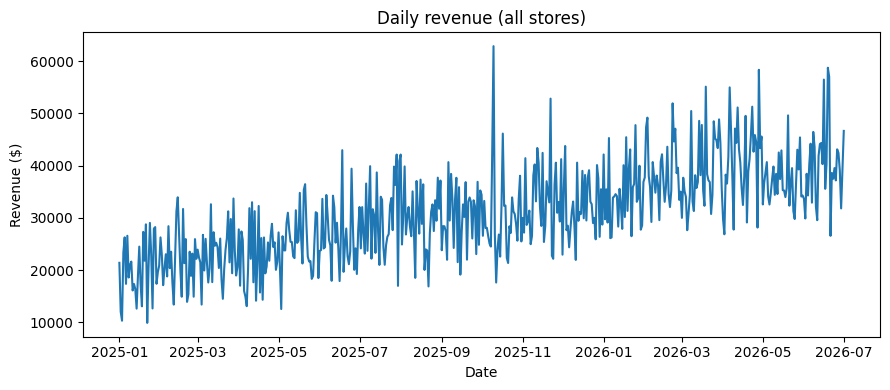

In [21]:
fig, ax = plt.subplots()
ax.plot(daily_sales.groupby("date")["revenue"].sum())
ax.set_title("Daily revenue (all stores)")
ax.set_xlabel("Date"); ax.set_ylabel("Revenue ($)")
plt.tight_layout(); plt.show()

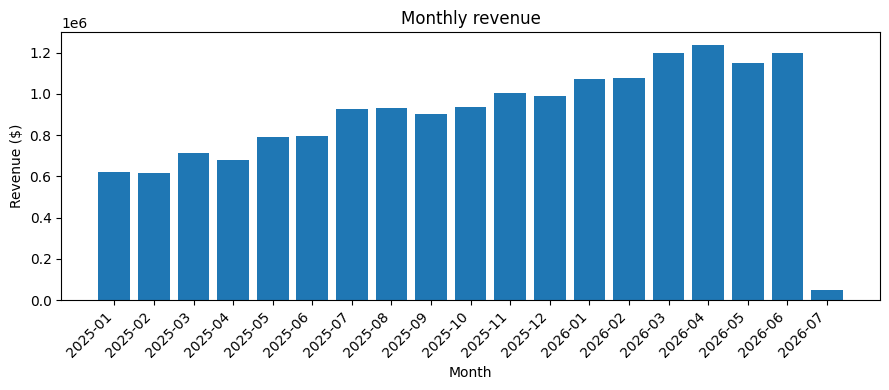

In [22]:
fig, ax = plt.subplots()
ax.bar(monthly_sales["month"], monthly_sales["revenue"])
ax.set_title("Monthly revenue")
ax.set_xlabel("Month"); ax.set_ylabel("Revenue ($)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()

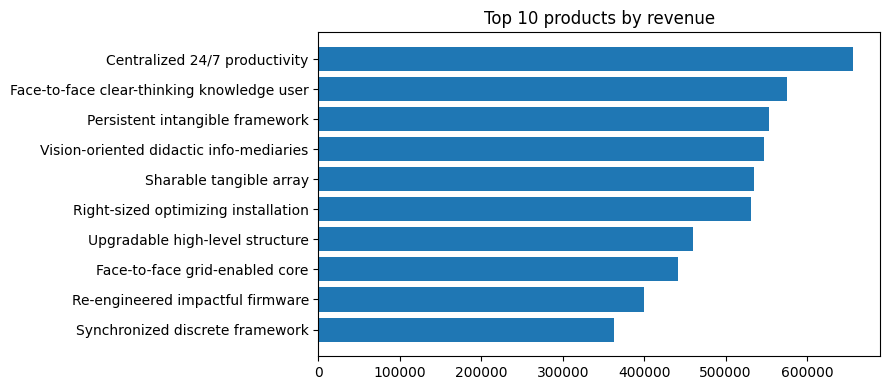

In [23]:
top10 = product_performance.nlargest(10, "revenue")
fig, ax = plt.subplots()
ax.barh(top10["product_name"], top10["revenue"])
ax.set_title("Top 10 products by revenue")
ax.invert_yaxis()
plt.tight_layout(); plt.show()

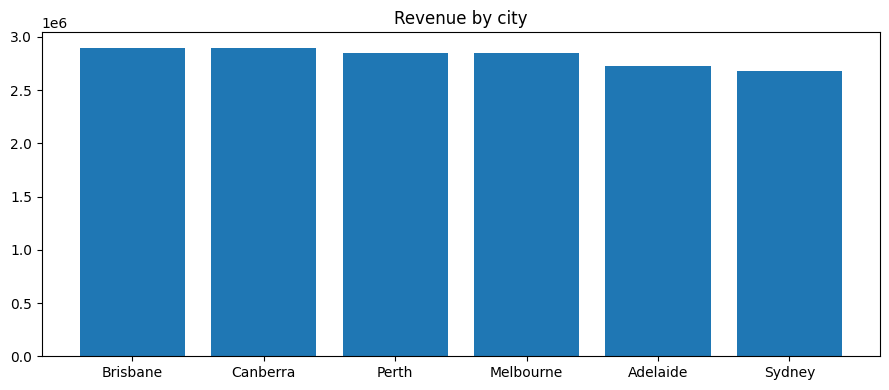

In [24]:
by_city = store_performance.groupby("city")["revenue"].sum().sort_values(ascending=False)
fig, ax = plt.subplots()
ax.bar(by_city.index, by_city.values)
ax.set_title("Revenue by city")
plt.tight_layout(); plt.show()

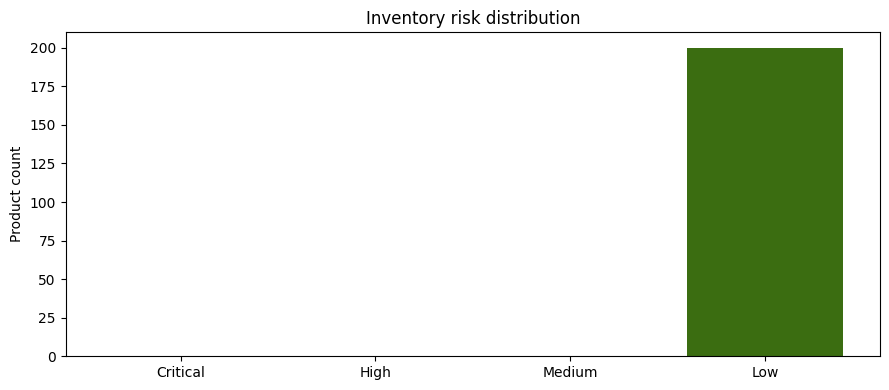

In [25]:
risk_order = ["Critical", "High", "Medium", "Low"]
risk_counts = inventory_health["risk_level"].value_counts().reindex(risk_order).fillna(0)
fig, ax = plt.subplots()
ax.bar(risk_counts.index, risk_counts.values, color=["#a32d2d", "#993c1d", "#854f0b", "#3b6d11"])
ax.set_title("Inventory risk distribution")
ax.set_ylabel("Product count")
plt.tight_layout(); plt.show()

## Final summary

In [26]:
tables_written = {
    "customer_summary": customer_summary,
    "daily_sales": daily_sales,
    "monthly_sales": monthly_sales,
    "product_performance": product_performance,
    "store_performance": store_performance,
    "inventory_health": inventory_health,
    "marketing_performance": marketing_performance,
    "returns_summary": returns_summary,
}

status_by_table = summary.set_index("table")["status"].to_dict()

print(f"{'Analytics table':<24}{'Rows':>8}{'Columns':>10}   Validation")
print("-" * 58)
for name, df in tables_written.items():
    print(f"{name:<24}{len(df):>8,}{len(df.columns):>10}   {status_by_table.get(name, 'UNKNOWN')}")

print(f"\nOutput directory: {OUT_DIR.resolve()}")

Analytics table             Rows   Columns   Validation
----------------------------------------------------------
customer_summary           5,000        11   PASS
daily_sales                4,376         9   PASS
monthly_sales                 19         6   PASS
product_performance          200         8   PASS
store_performance              8         7   PASS
inventory_health             200         6   PASS
marketing_performance         30         9   PASS
returns_summary              200         5   PASS

Output directory: /home/claude/project/eaida/data/analytics
